# Pulling Data


Bajamos la información directamente de Kaggle, usando la API 


Problema House Prices https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data

In [13]:
import os
import requests
from getpass import getpass
from kaggle.api.kaggle_api_extended import KaggleApi
from dotenv import load_dotenv
load_dotenv()

kaggle_token = os.getenv("KAGGLE_API_TOKEN")
api = KaggleApi()
api.authenticate()

try:
    api.competition_download_file(
        "house-prices-advanced-regression-techniques",
        "train.csv",
        path="./"
    )
except requests.HTTPError as error:
    
    raise

try:
    api.competition_download_file(
        "house-prices-advanced-regression-techniques",
        "test.csv",
        path="./"
    )
except requests.HTTPError as error:
    
    raise

Authentication required to call the Kaggle API.

First, you will need a Kaggle account. You can sign up at
  https://www.kaggle.com/account/login

Recommended: log in with OAuth via a web-based authorization flow.
No token to manage; credentials are cached locally for you.
    kaggle auth login

If you'd rather not use OAuth, generate an API token at
  https://www.kaggle.com/settings/api  (click "Generate New Token" under "API")
and supply it to the CLI in one of these ways:

  Option A: Environment variable
    export KAGGLE_API_TOKEN=xxxxxxxxxxxxxx  # token copied from the settings UI

  Option B: API token file
    Save the token to ~/.kaggle/access_token


NameError: name 'exit' is not defined

# Separación Entrenamiento y Prueba

Los datos de la competencia de Kaggle ya vienen divididos en un conjunto de entrenamiento y uno de prueba, este último sin la variable objetivo (SalePrice), por lo que funciona como un conjunto de validación externo para el modelo. Por esta razón, la exploración y preparación de datos se realiza únicamente sobre el conjunto de entrenamiento (tran.csv), el cual se divide adicionalmente de forma aleatoria en 80% para entrenamiento y 20% para prueba, con el fin de poder evaluar el desempeño del modelo antes de aplicarlo al conjunto de validación.




In [4]:
import pandas as pd


train_test_df = pd.read_csv("train.csv")
validation_df = pd.read_csv("test.csv")

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    train_test_df, test_size=0.2, random_state=80
)

print("Metodo utilizado: train_test_split (particion aleatoria) de scikit-learn")


print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Validation shape:", validation_df.shape)
print("Diferencia de columnas:", train_df.shape[1] - validation_df.shape[1], "(train tiene SalePrice, test no)")
print(f"Porcentaje para entrenamiento: {len(train_df) / len(train_test_df):.0%}")
print(f"Porcentaje para prueba: {len(test_df) / len(train_test_df):.0%}")


Metodo utilizado: train_test_split (particion aleatoria) de scikit-learn
Train shape: (1168, 81)
Test shape: (292, 81)
Validation shape: (1459, 80)
Diferencia de columnas: 1 (train tiene SalePrice, test no)
Porcentaje para entrenamiento: 80%
Porcentaje para prueba: 20%


# Exploración Inicial

In [14]:
import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)


print("Train dataset shape:", train_df.shape)
print("Train dataset columns:", train_df.columns)
print("Train dataset Variables Predictoras Posibles:", train_df.shape[1]-2) # id y target
print("Train dataset Variables Objetivo:", 1, ": Precio de Venta") # target
print("Train dataset Datos de Entrenamiento:", train_df.shape[0]) 
print("Train dataset head:")
train_df.head()


Train dataset shape: (1168, 81)
Train dataset columns: Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'Gara

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1333,1334,50,RM,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,IDOTRR,Norm,Norm,1Fam,1.5Fin,5,6,1938,1995,Gable,CompShg,Wd Sdng,Wd Sdng,NaN,0.0,TA,TA,CBlock,TA,TA,No,Unf,0,Unf,0,803,803,GasA,Ex,Y,SBrkr,803,557,0,1360,0,0,1,1,2,1,Gd,6,Typ,0,NaN,Detchd,1951.0,Unf,1,297,TA,TA,Y,0,65,190,0,0,0,NaN,MnPrv,NaN,0,7,2006,WD,Normal,125500
849,850,80,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,SLvl,6,7,1976,1994,Hip,CompShg,Plywood,Plywood,BrkFace,360.0,Gd,Gd,CBlock,TA,TA,No,Unf,0,Unf,0,528,528,GasA,Ex,Y,SBrkr,1094,761,0,1855,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1976.0,RFn,2,512,TA,TA,Y,113,100,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,187000
647,648,20,RL,85.0,10452,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,1Story,6,5,1953,1953,Hip,CompShg,Wd Sdng,Wd Sdng,Stone,216.0,TA,TA,CBlock,TA,TA,Mn,Rec,500,Unf,0,594,1094,GasA,Ex,Y,SBrkr,1094,0,0,1094,0,0,1,0,3,1,TA,5,Typ,2,Gd,Attchd,1953.0,RFn,2,495,TA,TA,Y,0,0,0,0,287,0,NaN,NaN,NaN,0,6,2008,WD,Normal,155000
501,502,60,FV,75.0,9803,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,2Story,7,5,2005,2005,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,Gd,TA,PConc,Gd,TA,No,GLQ,400,Unf,0,466,866,GasA,Gd,Y,SBrkr,866,902,0,1768,0,0,2,1,3,1,Gd,7,Typ,0,NaN,Attchd,2005.0,RFn,2,603,TA,TA,Y,0,108,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,226700
1115,1116,20,RL,93.0,12085,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NridgHt,Norm,Norm,1Fam,1Story,8,5,2007,2007,Hip,CompShg,VinylSd,VinylSd,Stone,328.0,Gd,TA,PConc,Ex,TA,No,GLQ,1004,Unf,0,730,1734,GasA,Ex,Y,SBrkr,1734,0,0,1734,1,0,2,0,3,1,Ex,7,Typ,1,Gd,Attchd,2007.0,RFn,3,928,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,11,2007,New,Partial,318000


### Datos Faltantes


In [15]:
train_df.info()

missing_summary = (
    train_df.isna()
    .sum()
    .to_frame(name="datos_faltantes")
    .assign(
        porcentaje_faltante=lambda dataframe: (
            dataframe["datos_faltantes"] / len(train_df) * 100
        ).round(2)
    )
    .sort_values("porcentaje_faltante", ascending=False)
 )

missing_summary[missing_summary["datos_faltantes"] > 0]

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 1333 to 1199
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1168 non-null   int64  
 1   MSSubClass     1168 non-null   int64  
 2   MSZoning       1168 non-null   object 
 3   LotFrontage    961 non-null    float64
 4   LotArea        1168 non-null   int64  
 5   Street         1168 non-null   object 
 6   Alley          71 non-null     object 
 7   LotShape       1168 non-null   object 
 8   LandContour    1168 non-null   object 
 9   Utilities      1168 non-null   object 
 10  LotConfig      1168 non-null   object 
 11  LandSlope      1168 non-null   object 
 12  Neighborhood   1168 non-null   object 
 13  Condition1     1168 non-null   object 
 14  Condition2     1168 non-null   object 
 15  BldgType       1168 non-null   object 
 16  HouseStyle     1168 non-null   object 
 17  OverallQual    1168 non-null   int64  
 18  OverallCon

,datos_faltantes,porcentaje_faltante
PoolQC,1163,99.57
MiscFeature,1121,95.98
Alley,1097,93.92
Fence,938,80.31
MasVnrType,688,58.90
FireplaceQu,563,48.20
LotFrontage,207,17.72
GarageQual,66,5.65
GarageFinish,66,5.65
GarageType,66,5.65


### Metricas Descriptivas variables continuas

In [16]:
train_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,1168.0,NaN,NaN,NaN,723.375856,419.46729,1.0,358.75,726.5,1081.75,1458.0
MSSubClass,1168.0,NaN,NaN,NaN,58.403253,43.598789,20.0,20.0,50.0,70.0,190.0
MSZoning,1168,5,RL,910,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LotFrontage,961.0,NaN,NaN,NaN,69.864724,25.113833,21.0,59.0,70.0,80.0,313.0
LotArea,1168.0,NaN,NaN,NaN,10233.892123,7950.362245,1300.0,7406.75,9375.0,11461.5,164660.0
Street,1168,2,Pave,1163,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alley,71,2,Grvl,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LotShape,1168,4,Reg,741,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LandContour,1168,4,Lvl,1051,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Utilities,1168,1,AllPub,1168,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Distribución de columnas tipo texto por Variable

Se Uso esta celda para explorar algunas variables de texto

In [17]:
c="GarageFinish"
train_df[c].value_counts()

GarageFinish
Unf    481
RFn    338
Fin    283
Name: count, dtype: int64

### Distribución de Variable Objetivo Sales Price

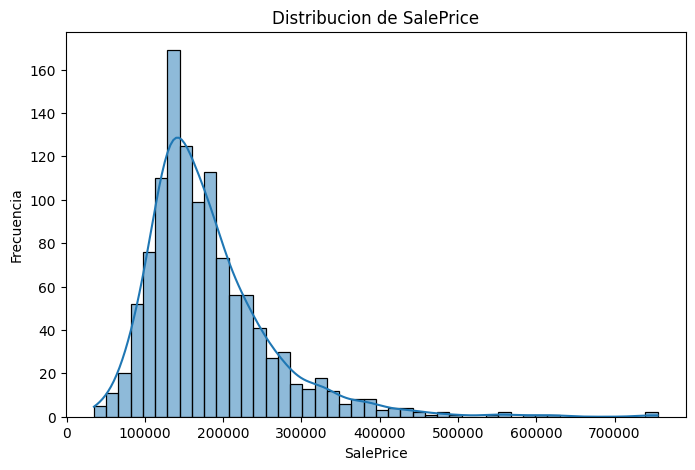

Skewness: 2.000511638642172


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(train_df["SalePrice"], kde=True)
plt.title("Distribucion de SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frecuencia")
plt.show()

print("Skewness:", train_df["SalePrice"].skew())


Se observa una distribución  en la cual hay casas que se venden por precios muy altos y que existen, es decir los eventos extremos pueden darse

### Analisis entre variables: Distribución de Variables Cualitivativas vs V. Objetivo

Se hacen las distribuciones de cada variable categorica / cualitativa para  determinar aquellas que tengan mayor impacto en la variable objetivo, siendo candidatas para ser seleccionadas en el modelo

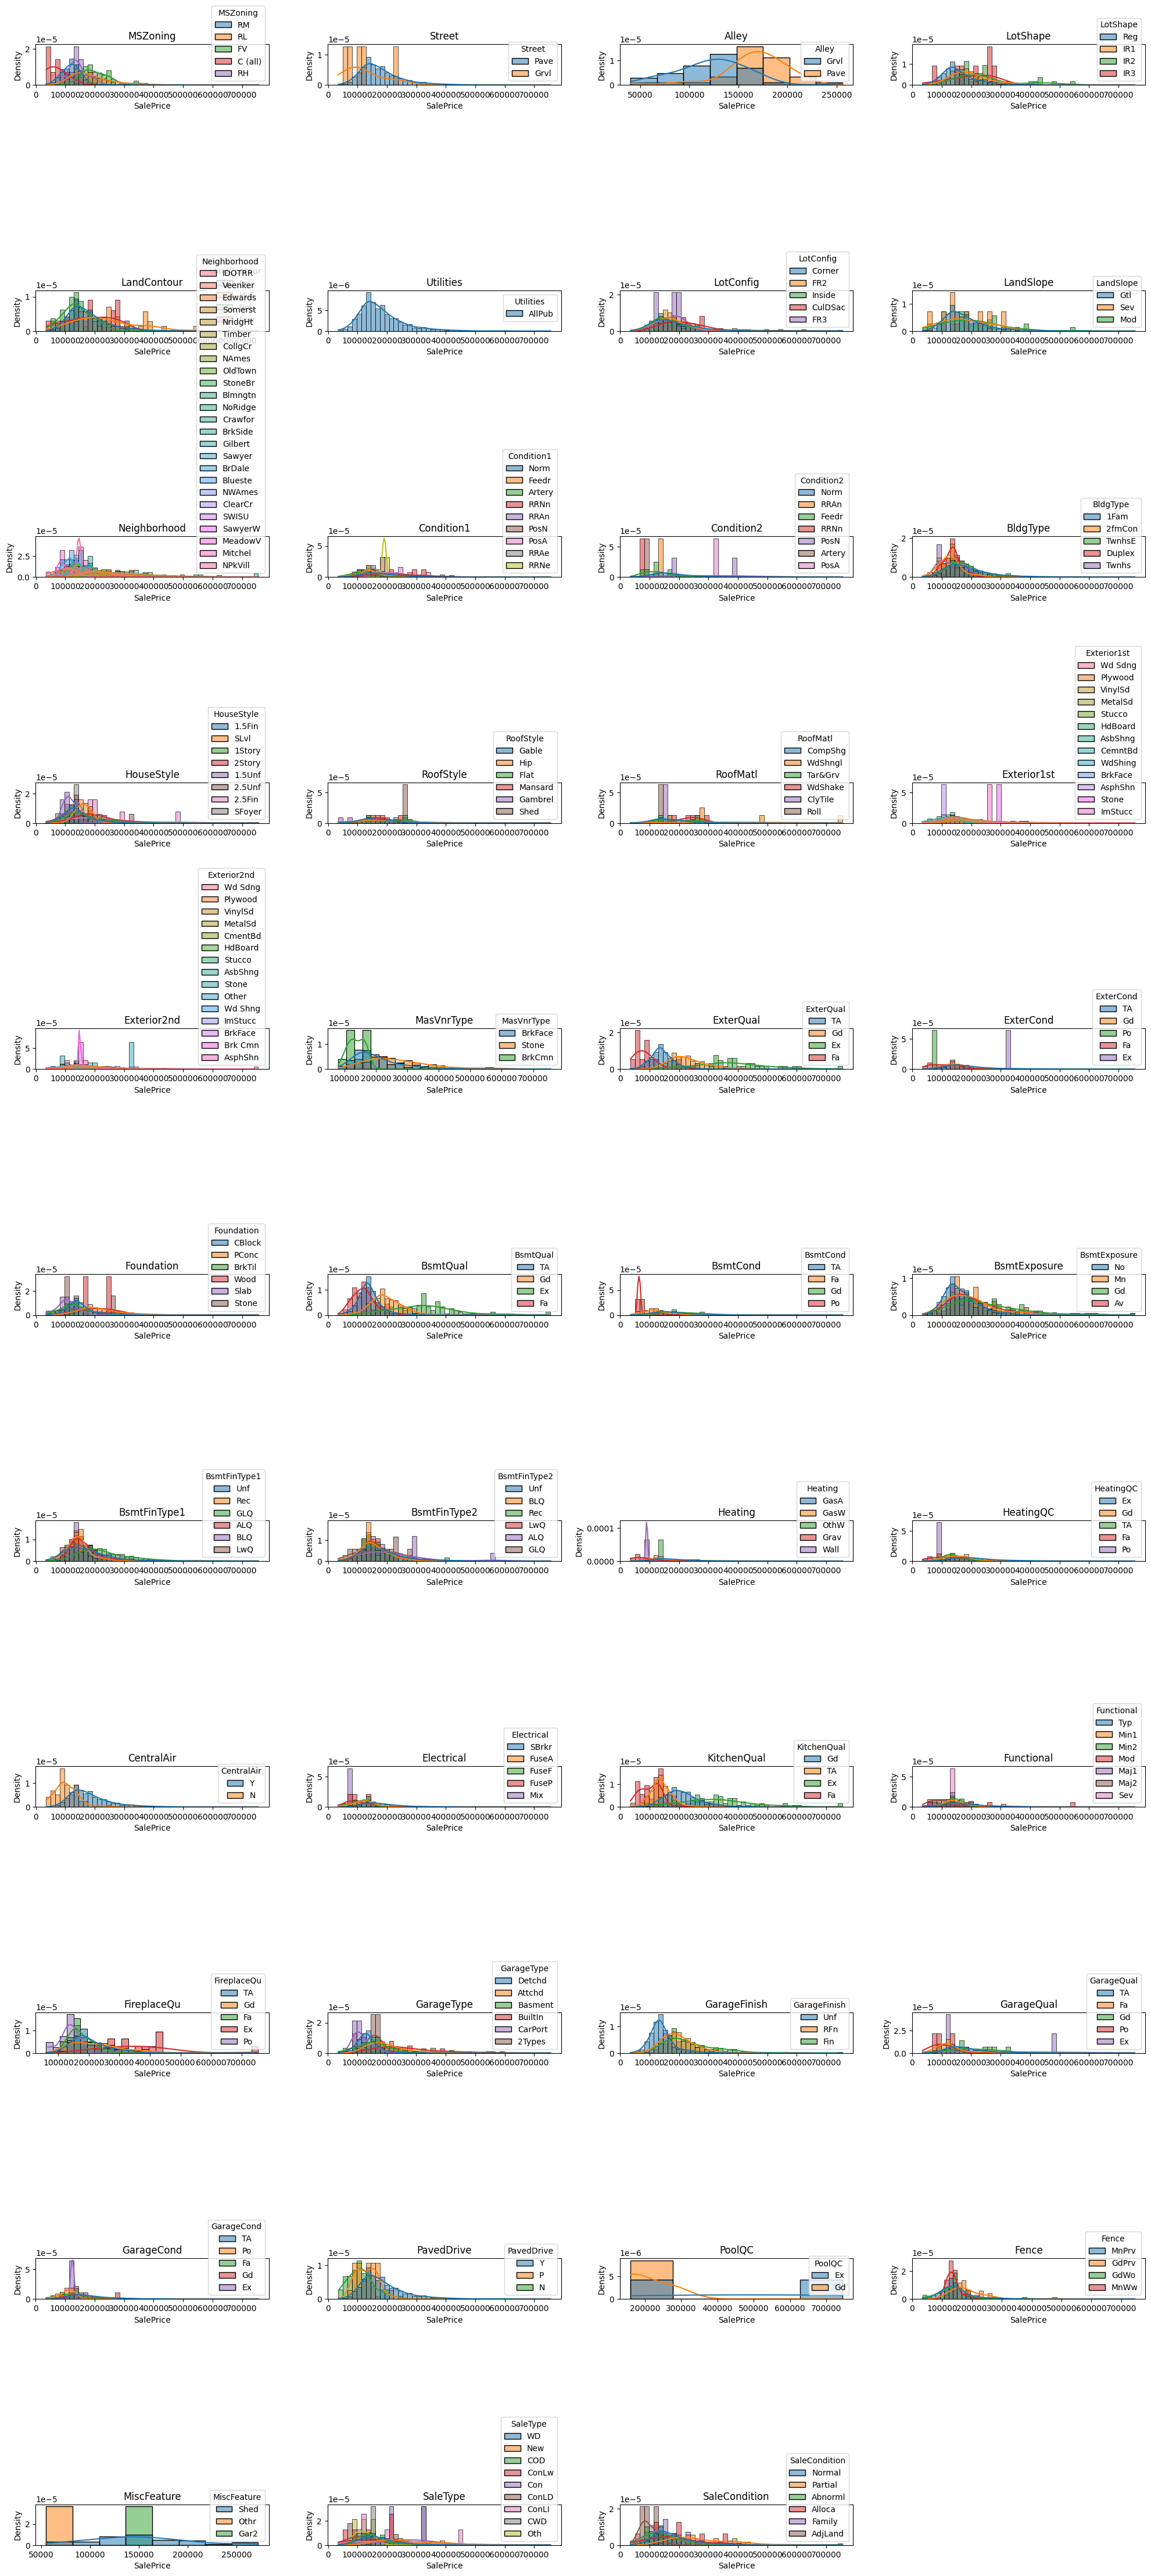

In [19]:



import math
import matplotlib.pyplot as plt
import seaborn as sns

categorical_columns = train_df.select_dtypes(include="object").columns.tolist()

n_cols = 4
n_rows = math.ceil(len(categorical_columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for ax, column in zip(axes, categorical_columns):
    sns.histplot(
        data=train_df,
        x="SalePrice",
        hue=column,
        kde=True,
        stat="density",
        common_norm=False,
        ax=ax,
    )
    ax.set_title(column)

for ax in axes[len(categorical_columns):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


### Matriz de Correlación - Variables Numericas 

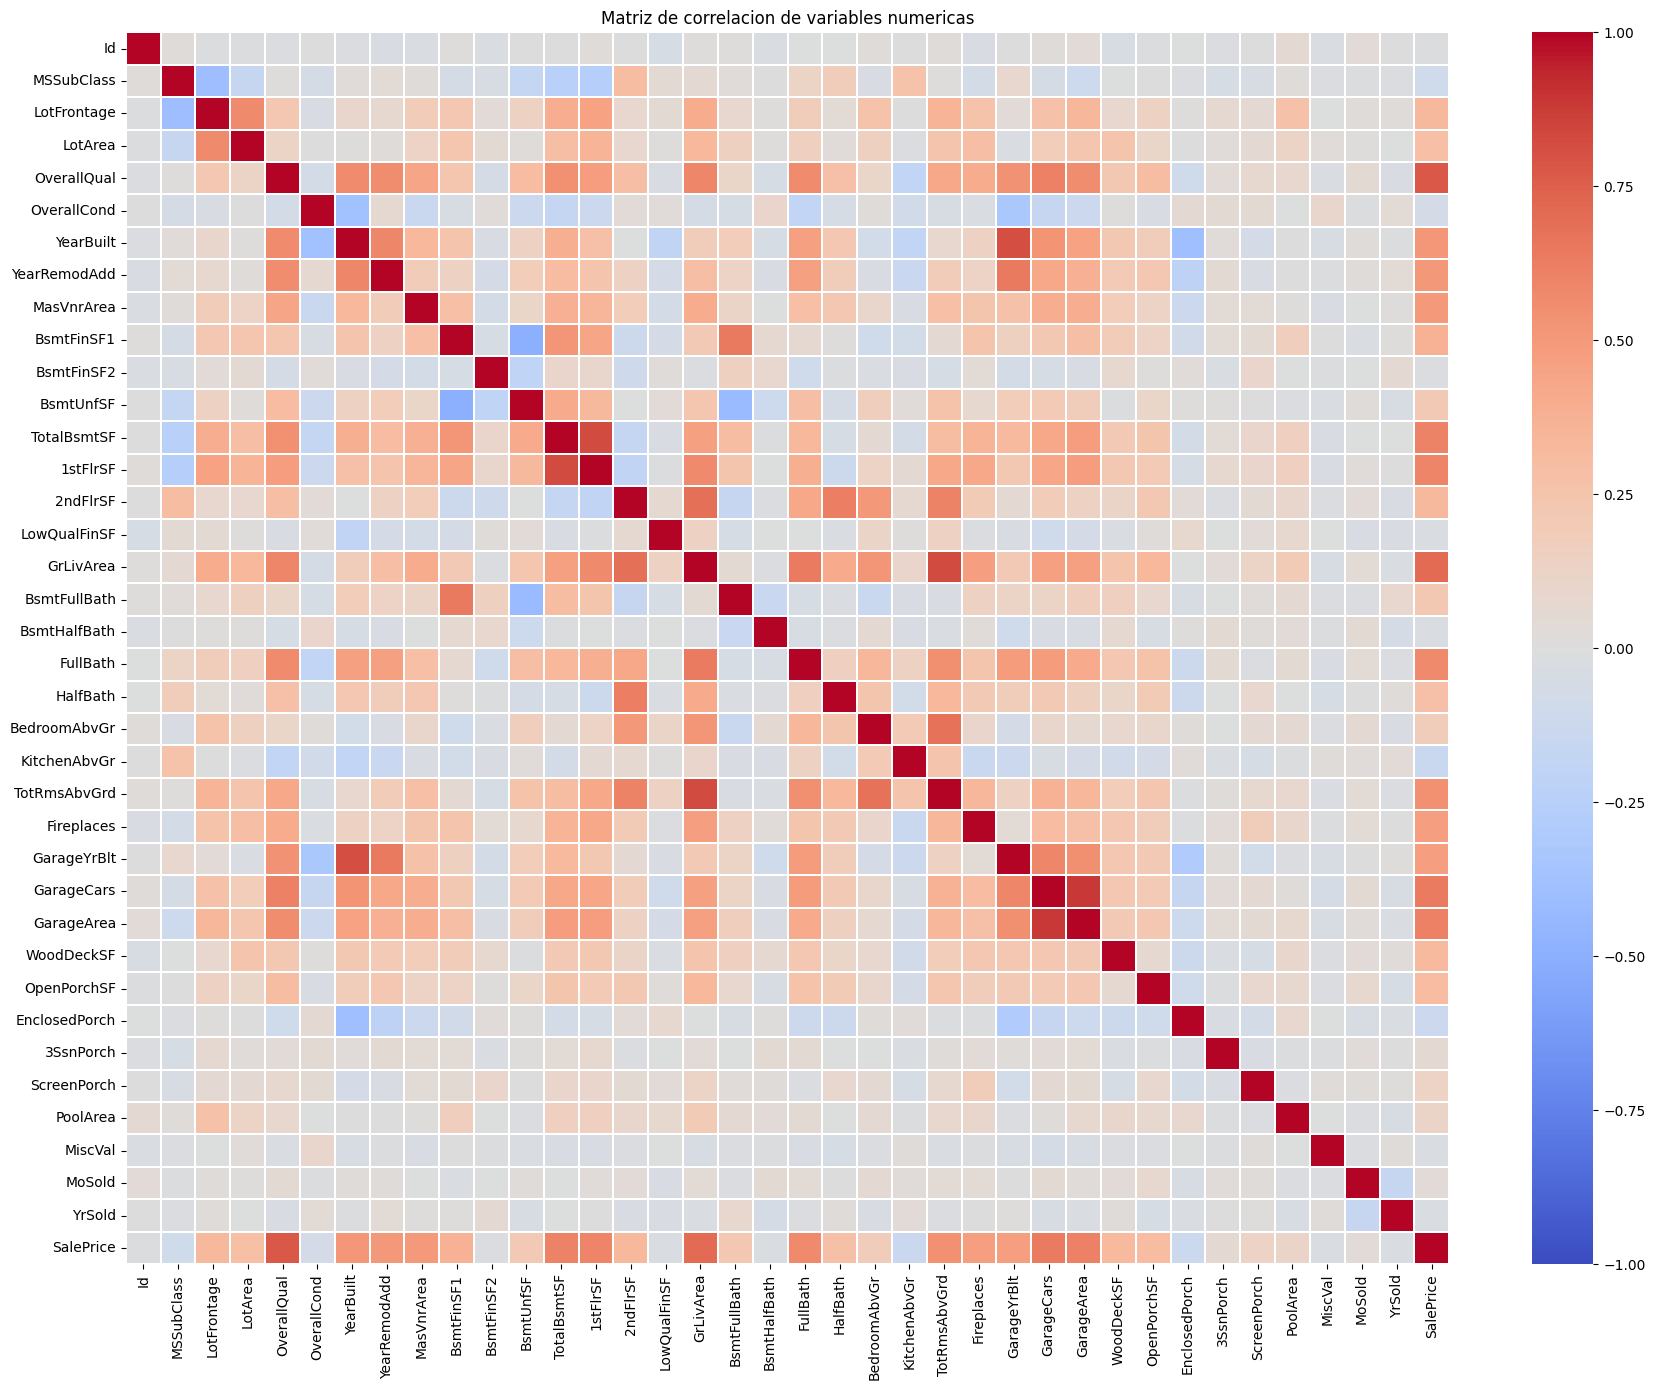

,correlacion_con_SalePrice
SalePrice,1.000000
OverallQual,0.781225
GrLivArea,0.704225
GarageCars,0.638980
GarageArea,0.612342
TotalBsmtSF,0.603924
1stFlrSF,0.600237
FullBath,0.577379
TotRmsAbvGrd,0.541112
YearBuilt,0.508800


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = train_df.select_dtypes(include="number").corr()

plt.figure(figsize=(18, 14))
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.2
)
plt.title("Matriz de correlacion de variables numericas")
plt.tight_layout()
plt.show()

correlation_with_target = (
    correlation_matrix["SalePrice"]
    .sort_values(ascending=False)
    .to_frame(name="correlacion_con_SalePrice")
 )

correlation_with_target

Se observa inicialmente que hay 13 posibles candidatas a ser variables predictoras por su correlación signficativa

Elimino las columnas que tengan baja correlación (menor a 0.6), ya que no son significativas a mi proceso

In [21]:
low_correlation_vars = correlation_with_target[
    correlation_with_target["correlacion_con_SalePrice"].abs() < 0.6
]
low_correlation_vars


,correlacion_con_SalePrice
FullBath,0.577379
TotRmsAbvGrd,0.541112
YearBuilt,0.508800
YearRemodAdd,0.507654
MasVnrArea,0.499492
Fireplaces,0.472070
GarageYrBlt,0.470641
BsmtFinSF1,0.373654
LotFrontage,0.325793
2ndFlrSF,0.324008


### Matriz Dispersion y distribucion

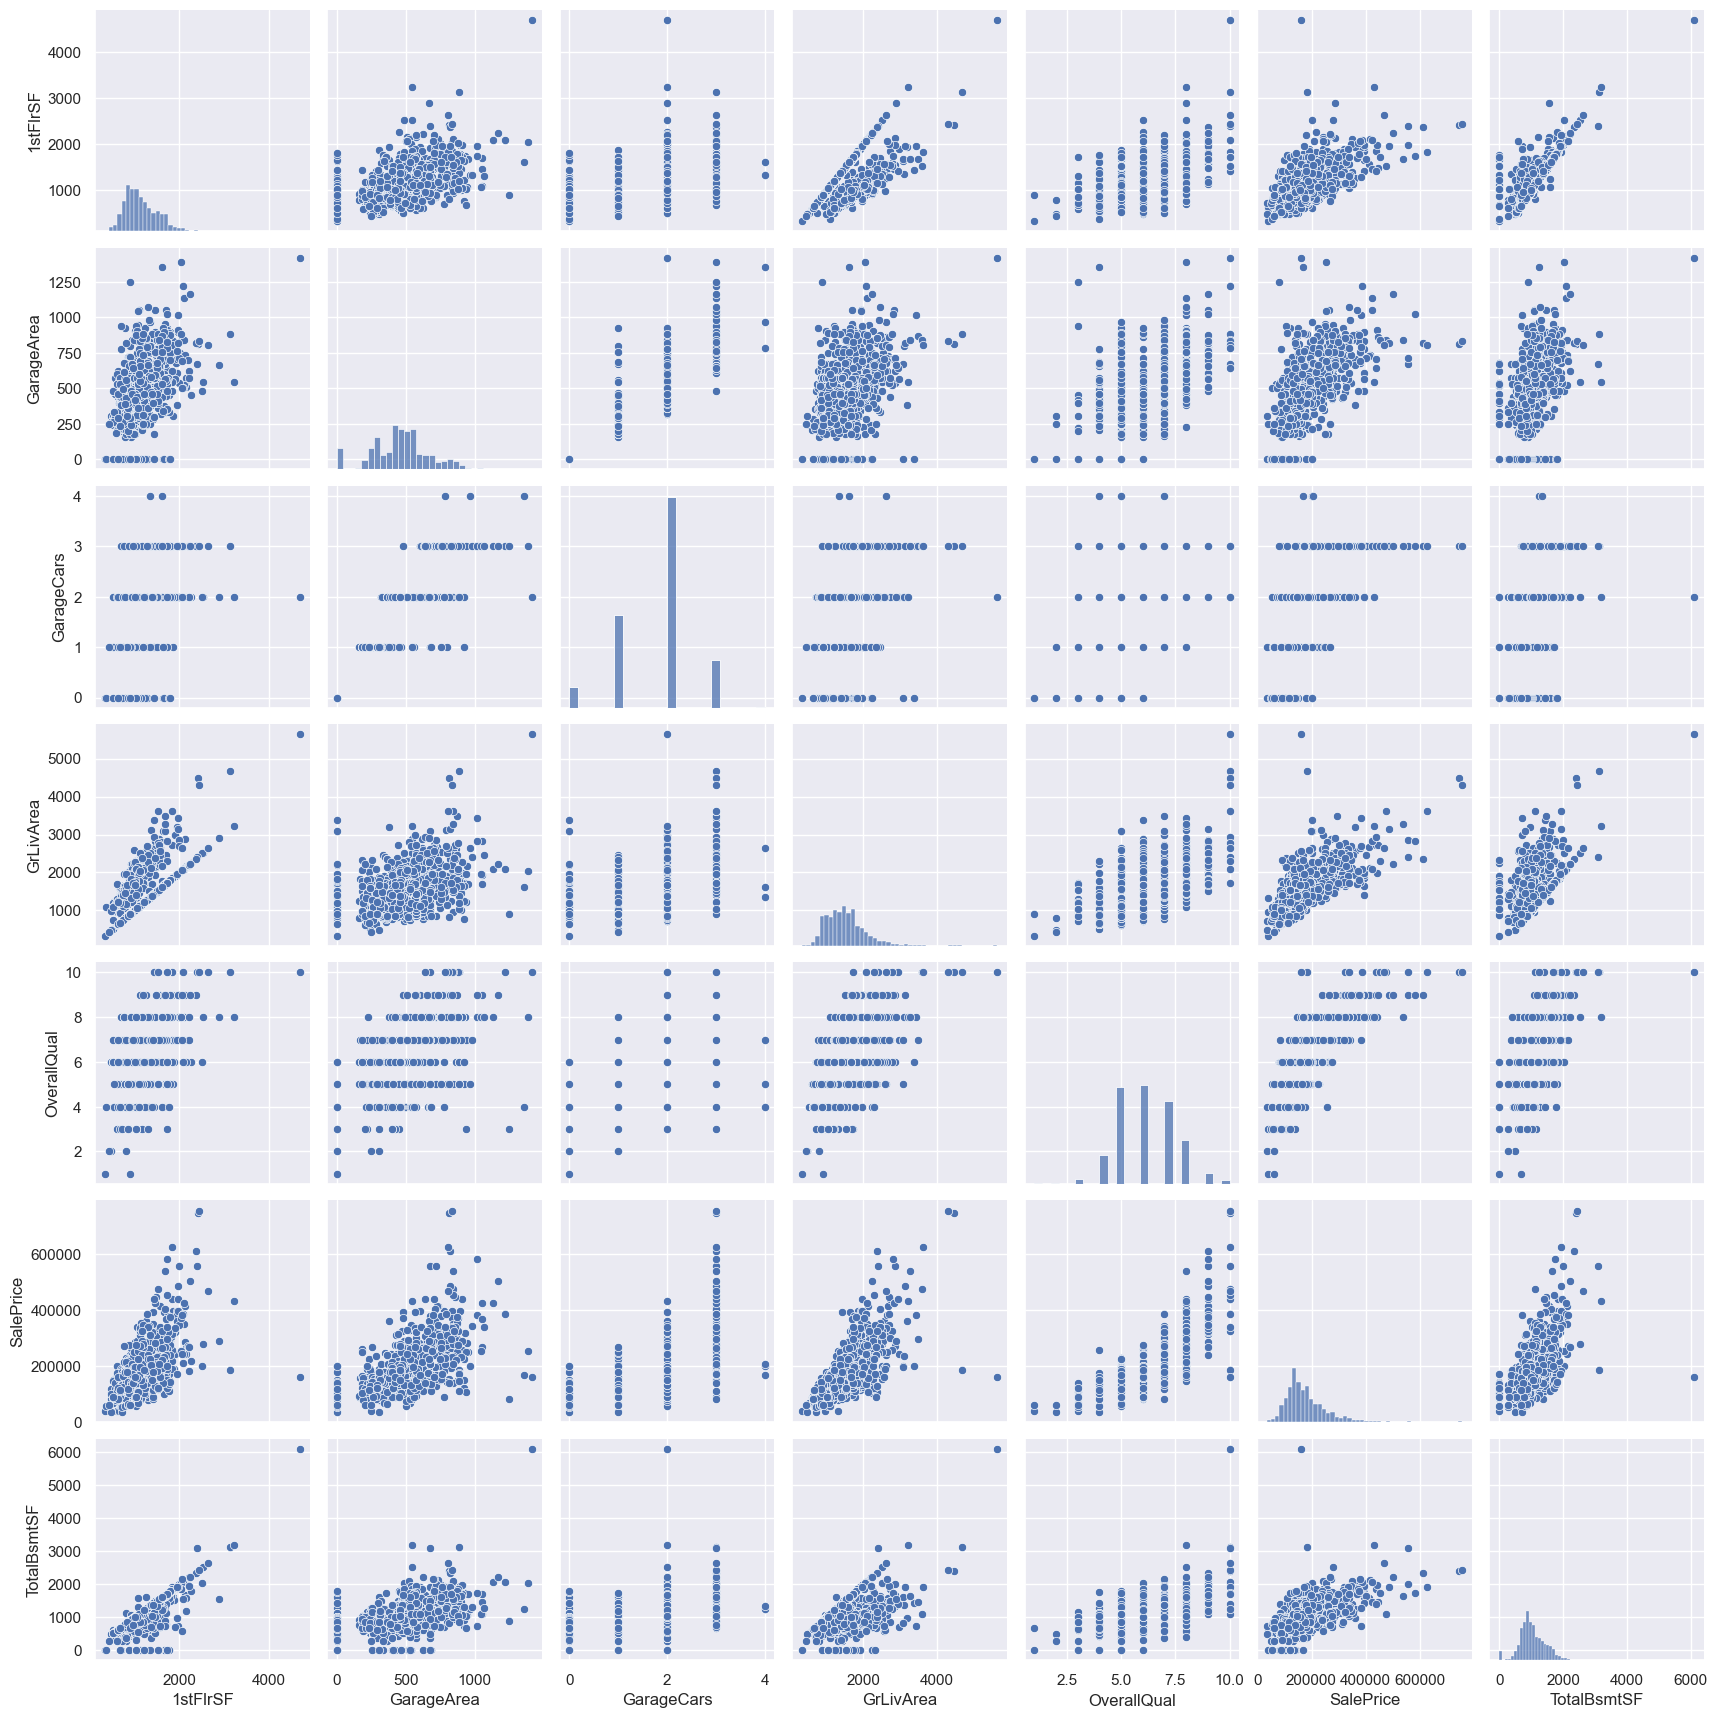

In [22]:
cols = correlation_with_target.index.difference(low_correlation_vars.index).tolist()
sns.set()
sns.pairplot(train_df[cols])


# Preparación de datos

### Eliminación de Variables Inicial

In [23]:
#1. Elimino las columnas que tienen mas del 40% de datos faltantes, 
# ya que no aportan informacion relevante al modelo y pueden generar ruido en el mismo.
columns_to_drop = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "MasVnrType",
    "FireplaceQu",
]

#2. Elimino columnas categoricas que, tras inspeccionar la distribucion de SalePrice
# por categoria, no aportan poder predictivo: son casi constantes o no muestran
# diferencias relevantes en el target entre sus categorias.
columns_to_drop_round2 = {
    "Street": "Se comporta como constante, poca variación en las etiquetas",
    "Utilities": "Se comporta como constante, poca variación en las etiquetas",
    "LotShape": "No hay variaciones significativas en la distribucion de SalePrice",
    "LandContour": "Se comporta como constante, poca variación en las etiquetas",
    "LotConfig": "No hay diferencias significativas en SalePrice",
    "LandSlope": "No hay diferencias significativas en SalePrice",
    "Condition2": "Se comporta como constante, poca variación en las etiquetas",
    "BldgType": "Misma respuesta en SalePrice entre categorias",
    "RoofStyle": "Misma respuesta en SalePrice entre categorias",
    "RoofMatl": "Misma respuesta en SalePrice entre categorias",
    "Exterior1st": "Misma respuesta en SalePrice entre categorias",
    "Exterior2nd": "Misma respuesta en SalePrice entre categorias",
    "ExterCond": "Misma respuesta en SalePrice entre categorias",
    "HouseStyle": "Misma respuesta en SalePrice entre categorias",
    "Foundation": "Misma respuesta en SalePrice entre categorias",
    "BsmtCond": "Misma respuesta en SalePrice entre categorias",
    "BsmtExposure": "Misma respuesta en SalePrice entre categorias",
    "BsmtFinType1": "Misma respuesta en SalePrice entre categorias",
    "BsmtFinType2": "Misma respuesta en SalePrice entre categorias",
    "Heating": "Se comporta como constante, poca variación en las etiquetas",
    "HeatingQC": "Misma respuesta en SalePrice entre categorias",
    "GarageType": "Misma respuesta en SalePrice entre categorias",
    "GarageQual": "Misma respuesta en SalePrice entre categorias",
    "GarageCond": "Misma respuesta en SalePrice entre categorias",
    "PavedDrive": "Misma respuesta en SalePrice / Casi una constante",
    "SaleType": "Misma respuesta en SalePrice entre categorias",
    "SaleCondition": "Misma respuesta en SalePrice entre categorias",
    "Condition1":"Se comporta como constante, poca variación en las etiquetas",
    "Electrical": "Misma respuesta en SalePrice entre categorias",
    "Functional": "Misma respuesta en SalePrice entre categorias",
    "Neighborhood": "Muchas categorias, Posible ruida en la respuesta final",
    "MSZoning": "Misma respuesta en SalePrice entre categorias y poca variación en las etiquetas"
}



train_df_cleaned = train_df.drop(columns=columns_to_drop)
print("Train dataset shape despues del primer drop:", train_df_cleaned.shape)

train_df_cleaned = train_df_cleaned.drop(columns=list(columns_to_drop_round2.keys()))
print("Train dataset shape despues del segundo drop:", train_df_cleaned.shape)


#3. Elimino las variables numericas de baja correlacion con SalePrice
# (definidas en low_correlation_vars), ya que aportan poco poder predictivo al modelo.
train_df_cleaned = train_df_cleaned.drop(columns=low_correlation_vars.index, errors="ignore")
print("Train dataset shape despues de eliminar variables de baja correlacion:", train_df_cleaned.shape)


Train dataset shape despues del primer drop: (1168, 75)
Train dataset shape despues del segundo drop: (1168, 43)
Train dataset shape despues de eliminar variables de baja correlacion: (1168, 12)


### Puntos Atipicos

In [24]:
train_df_cleaned.sort_values("TotalBsmtSF", ascending=False)[
    [ "TotalBsmtSF", "1stFlrSF", "GrLivArea", "SalePrice"]
].head(10)

,TotalBsmtSF,1stFlrSF,GrLivArea,SalePrice
1298,6110,4692,5642,160000
496,3200,3228,3228,430000
523,3138,3138,4676,184750
440,3094,2402,2402,555000
1373,2633,2633,2633,466500
1044,2524,2524,2524,278000
691,2444,2444,4316,755000
1182,2396,2411,4476,745000
898,2330,2364,2364,611657
888,2217,2217,2217,268000


Se observa que el registro 1298 tiene niveles alto en total BSM Sf, 1STSF y GRLIv Area, a pesar de eso su precio es mas bajo que otros registros con cualidades menores. Por lo que se descarta para no confundir al modelo con este punto atipico

In [25]:
train_df_cleaned = train_df_cleaned.drop(index=1298)
print("Train dataset shape despues de eliminar el registro atipico:", train_df_cleaned.shape)


Train dataset shape despues de eliminar el registro atipico: (1167, 12)


Se observa mejor comportamiento de los diagramas de dispersión

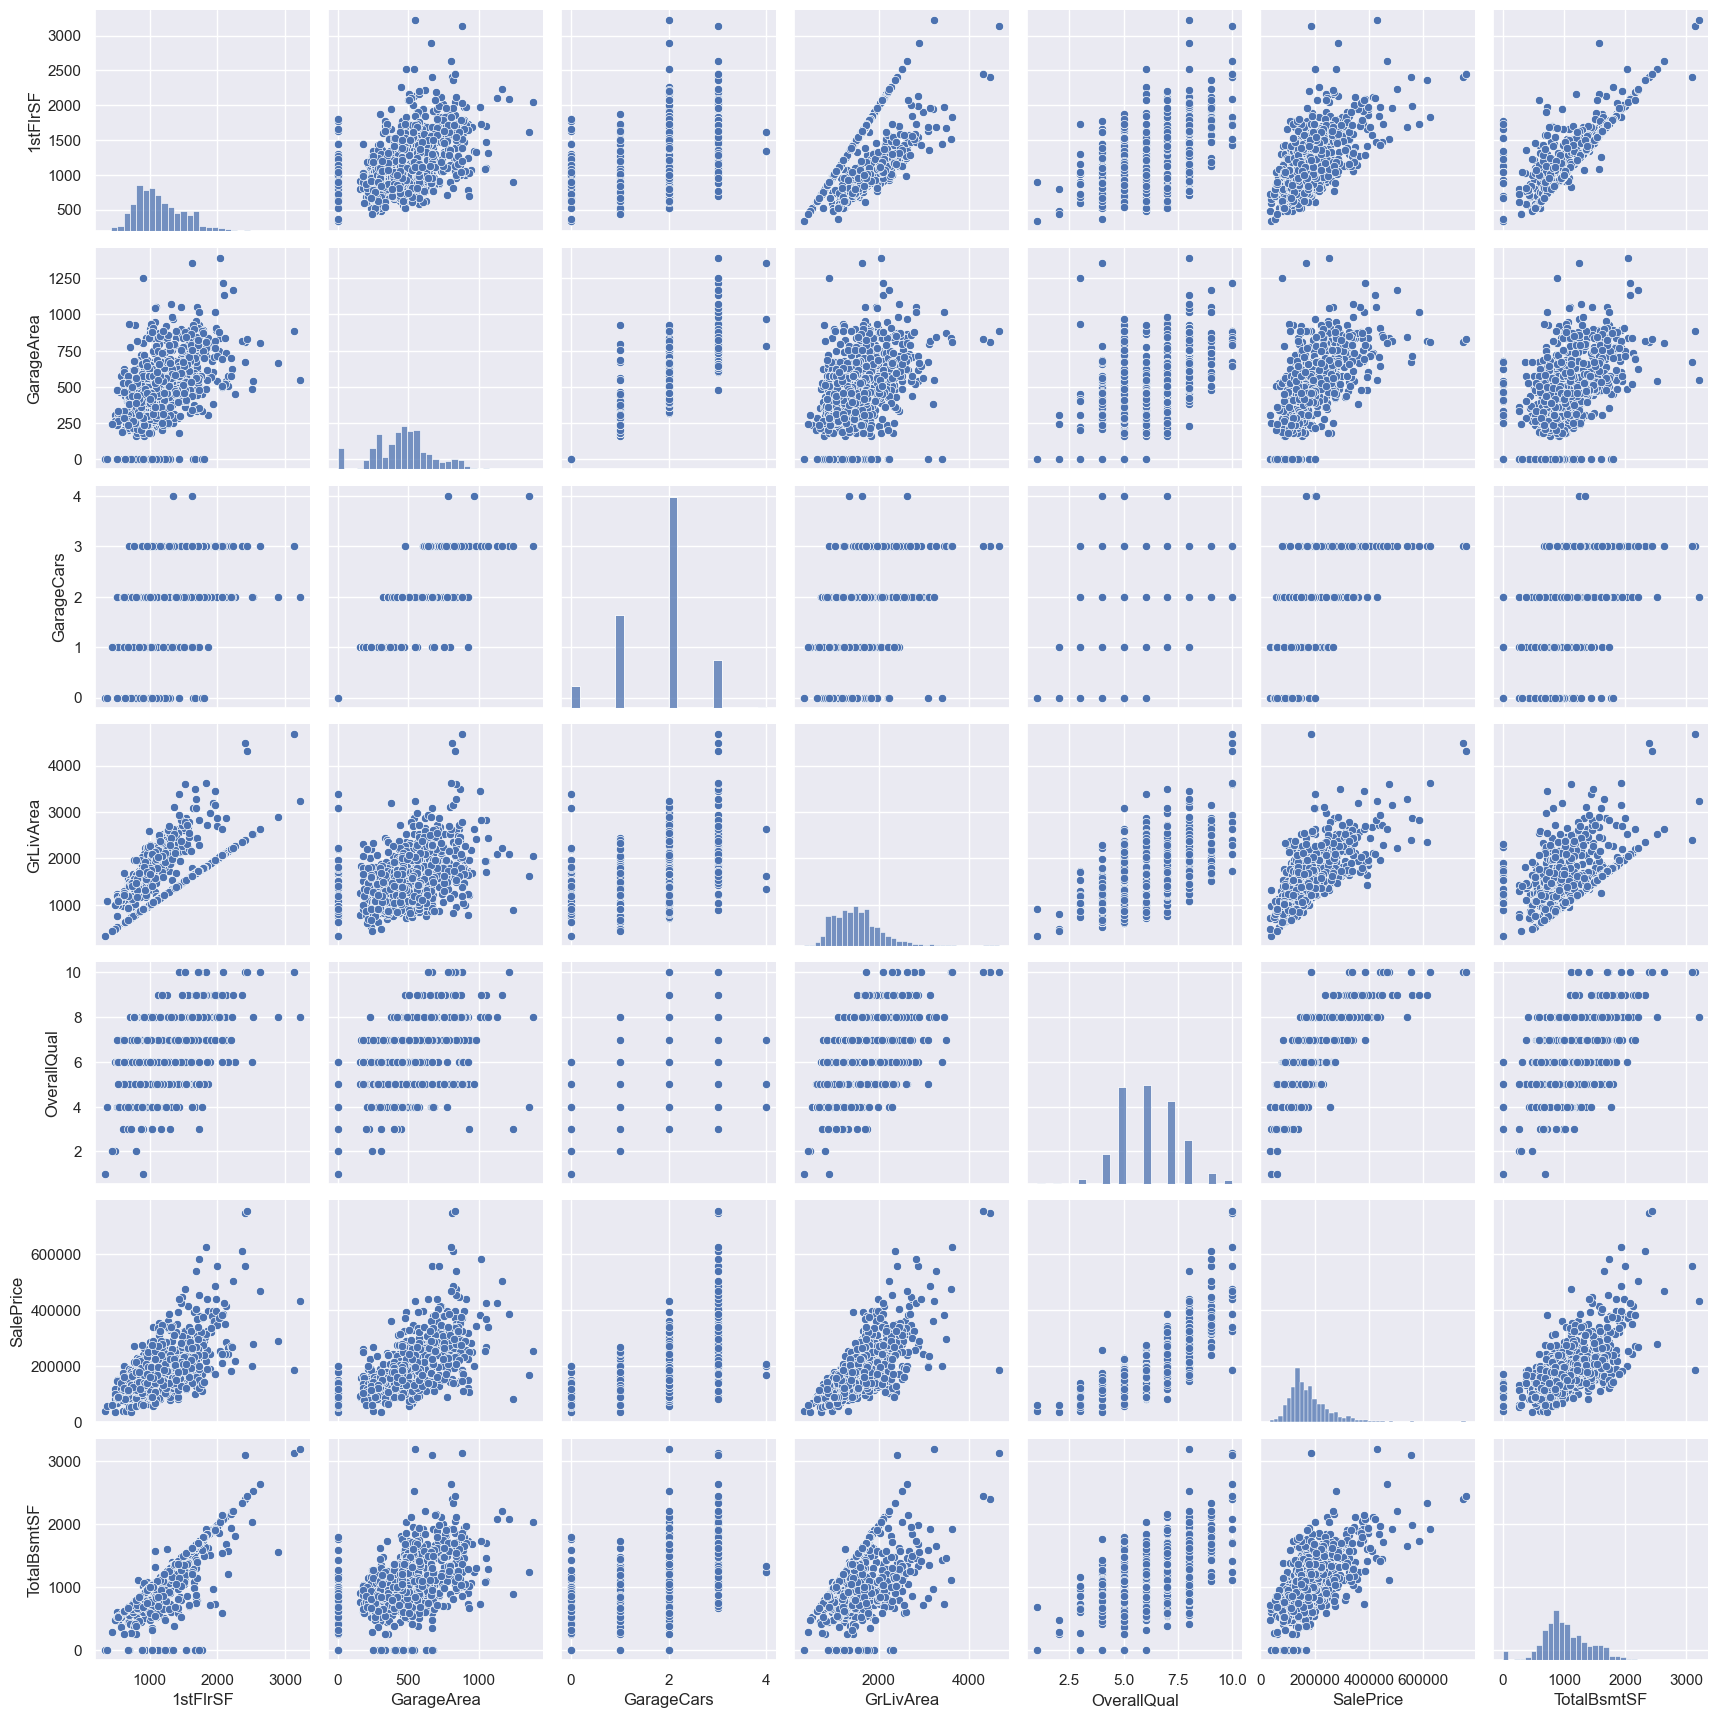

In [26]:
cols = correlation_with_target.index.difference(low_correlation_vars.index).tolist()
sns.set()
sns.pairplot(train_df_cleaned[cols])

### Matriz de Correlación - Variables Numercias 

Luego del primer filtro conviene observar si hay variables que presentan colinealidad, es decir que sean redudantes entre si

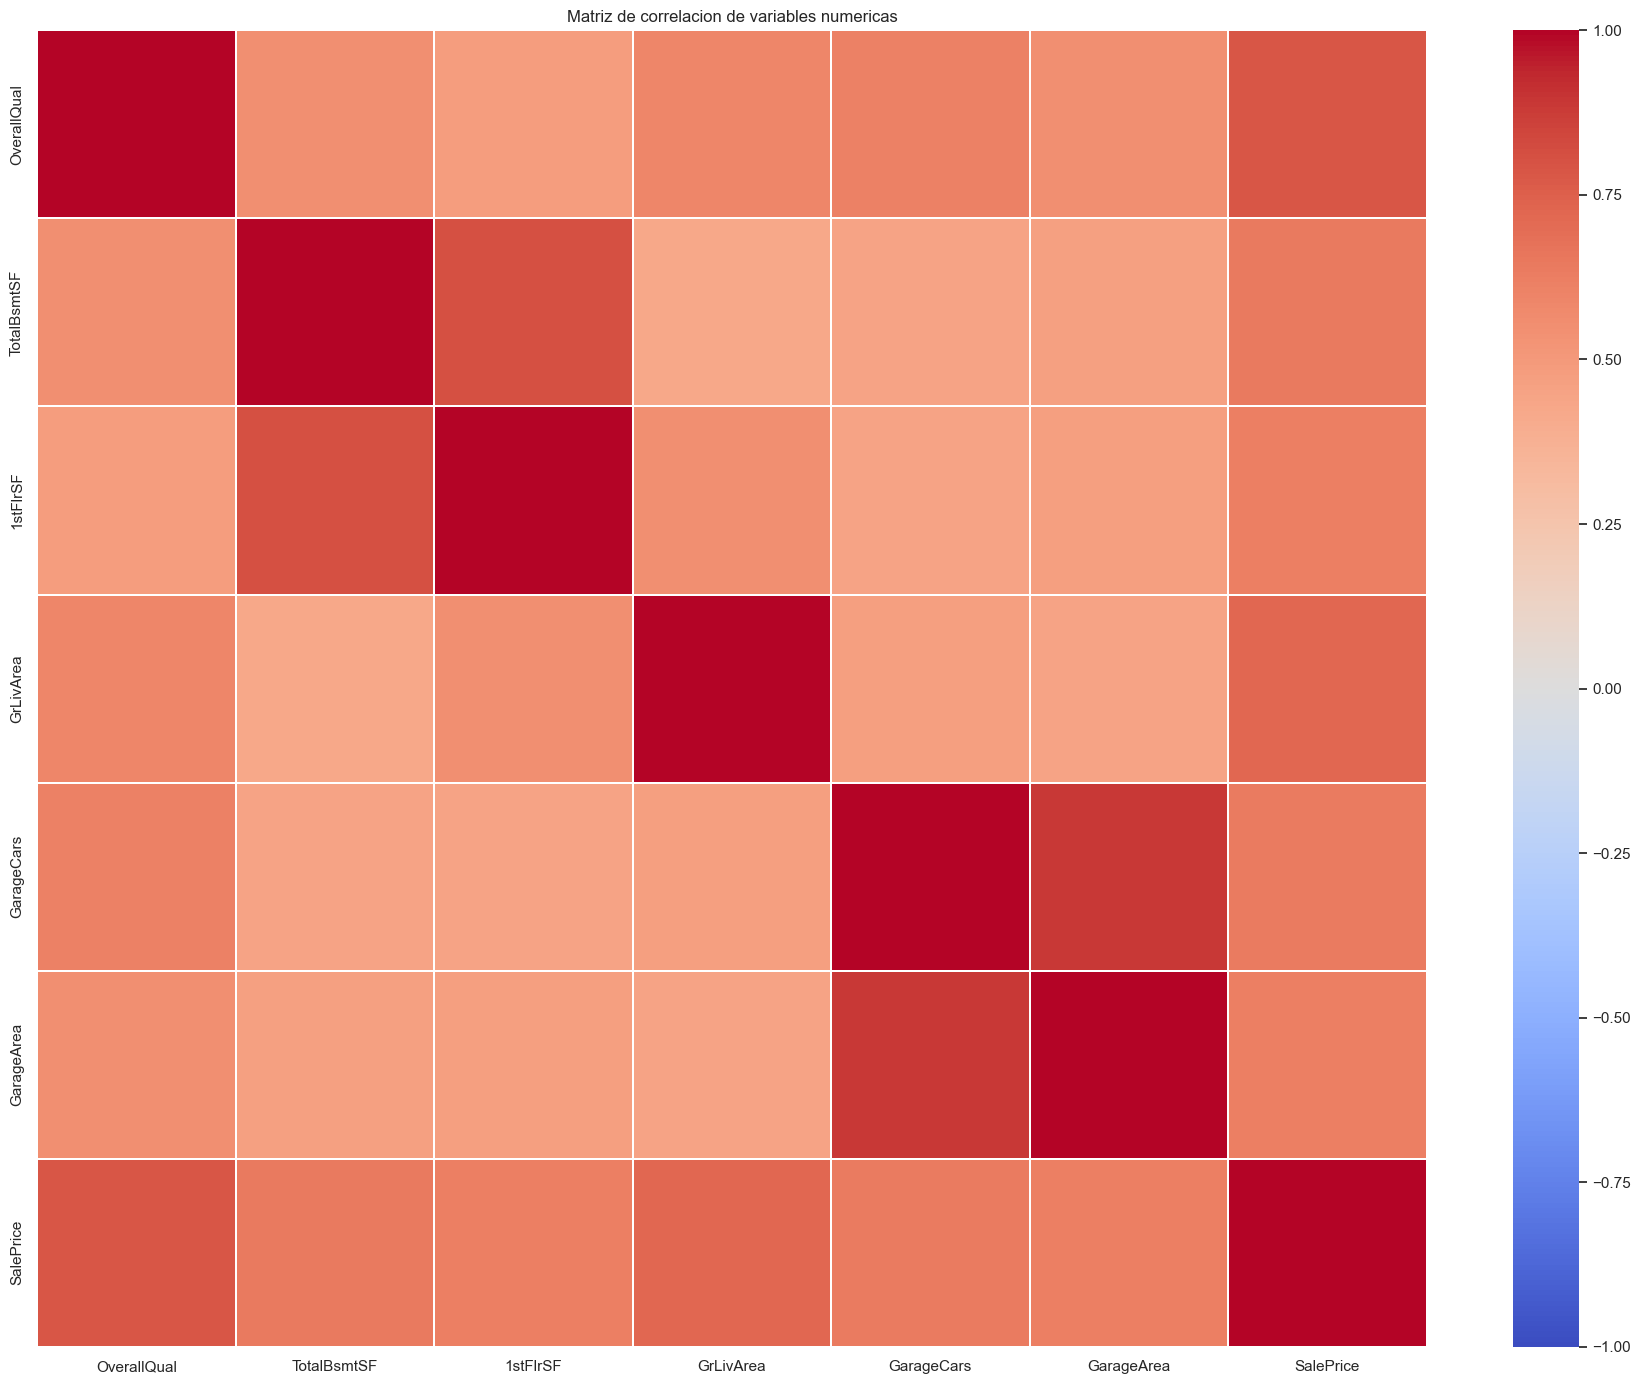

,correlacion_con_SalePrice
SalePrice,1.000000
OverallQual,0.784556
GrLivArea,0.724862
TotalBsmtSF,0.644175
GarageCars,0.639093
1stFlrSF,0.624397
GarageArea,0.618424


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = train_df_cleaned.select_dtypes(include="number").corr()

plt.figure(figsize=(18, 14))
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.2
)
plt.title("Matriz de correlacion de variables numericas")
plt.tight_layout()
plt.show()

correlation_with_target = (
    correlation_matrix["SalePrice"]
    .sort_values(ascending=False)
    .to_frame(name="correlacion_con_SalePrice")
 )

correlation_with_target

In [28]:
train_df_cleaned.head()

,OverallQual,ExterQual,BsmtQual,TotalBsmtSF,CentralAir,1stFlrSF,GrLivArea,KitchenQual,GarageFinish,GarageCars,GarageArea,SalePrice
1333,5,TA,TA,803,Y,803,1360,Gd,Unf,1,297,125500
849,6,Gd,TA,528,Y,1094,1855,TA,RFn,2,512,187000
647,6,TA,TA,1094,Y,1094,1094,TA,RFn,2,495,155000
501,7,Gd,Gd,866,Y,866,1768,Gd,RFn,2,603,226700
1115,8,Gd,Ex,1734,Y,1734,1734,Ex,RFn,3,928,318000


Se observa que las variables seleccionadas hasta el momento cumplen con diferentes aspectos de valor de la casa, como los tamños del sotano, primer piso, garaje, 2 piso o más, calidades de algunas espacios, etc.  Se observa una correlación significativa entre GarageArea y  GarageCars, dado que ambas describen la capacidad en terminos de carros o pies cuadrados, se escoge la variable continua de pies cuadrados y se descarta la de garage cars para el modelo

In [29]:
train_df_cleaned = train_df_cleaned.drop(columns=["GarageCars"])
print("Train dataset shape despues de eliminar GarageCars:", train_df_cleaned.shape)


Train dataset shape despues de eliminar GarageCars: (1167, 11)


###  Transformación de Variables Categoricas

Se observan que algunas variables categoricas tienen el sufijo Qual, indicando que es una variable de calidad, lo que convierte que es una variable categorica con orden y es posible transformarlo a numerico

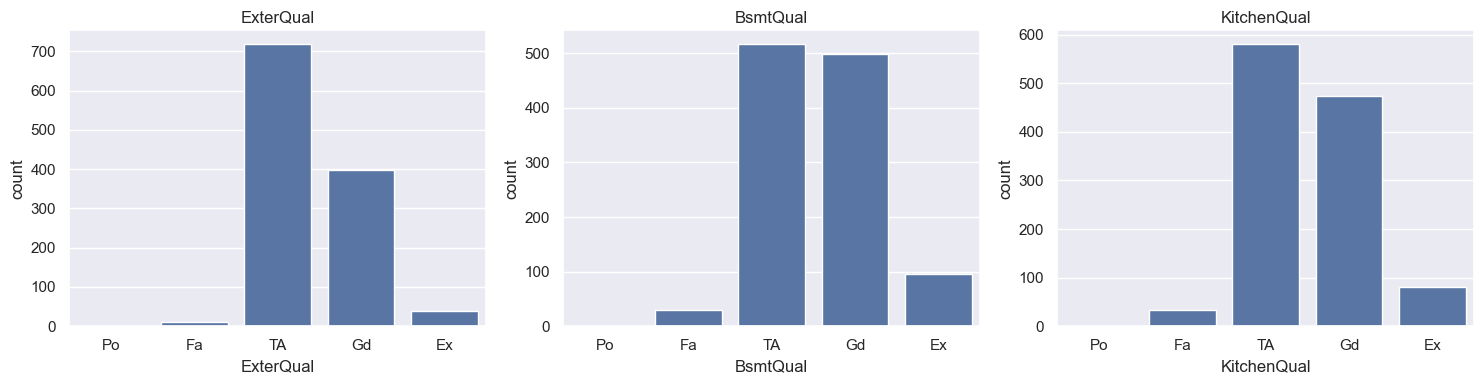

In [30]:
qual_cols = ["ExterQual", "BsmtQual", "KitchenQual"]

fig, axes = plt.subplots(1, len(qual_cols), figsize=(5 * len(qual_cols), 4))
for ax, c in zip(axes, qual_cols):
    sns.countplot(x=train_df_cleaned[c], order=["Po", "Fa", "TA", "Gd", "Ex"], ax=ax)
    ax.set_title(c)
plt.tight_layout()
plt.show()


Se concluye que la escala es consistente en las 3 variables, haciendo entonces un mapeoa una escala del 1-5

In [31]:
qual_mapping = {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}

for c in qual_cols:
    train_df_cleaned[c] = train_df_cleaned[c].map(qual_mapping)


Se observa que las categorías RFn y Fin de GarageFinish presentan una distribución de SalePrice muy similar entre sí, mientras que Unf se diferencia claramente de ambas. Por esta razón, se decide unificar RFn y Fin en una sola categoría (Fin), ya que separarlas no aporta información adicional relevante para predecir el precio de venta.

In [32]:
train_df_cleaned["GarageFinish"] = train_df_cleaned["GarageFinish"].replace("RFn", "Fin")


### Variables Categoricas Finales

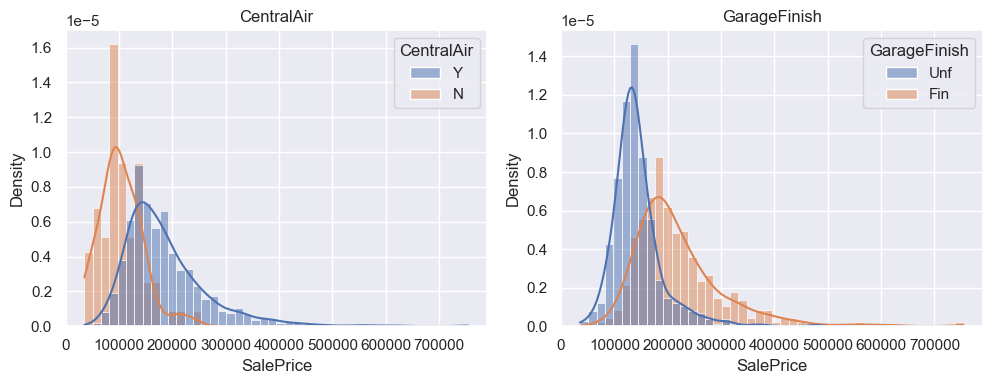

In [33]:

import math
import matplotlib.pyplot as plt
import seaborn as sns

categorical_columns = train_df_cleaned.select_dtypes(include="object").columns.tolist()

n_cols = 4
n_rows = math.ceil(len(categorical_columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for ax, column in zip(axes, categorical_columns):
    sns.histplot(
        data=train_df_cleaned,
        x="SalePrice",
        hue=column,
        kde=True,
        stat="density",
        common_norm=False,
        ax=ax,
    )
    ax.set_title(column)

for ax in axes[len(categorical_columns):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


### Variables Continuas Finales

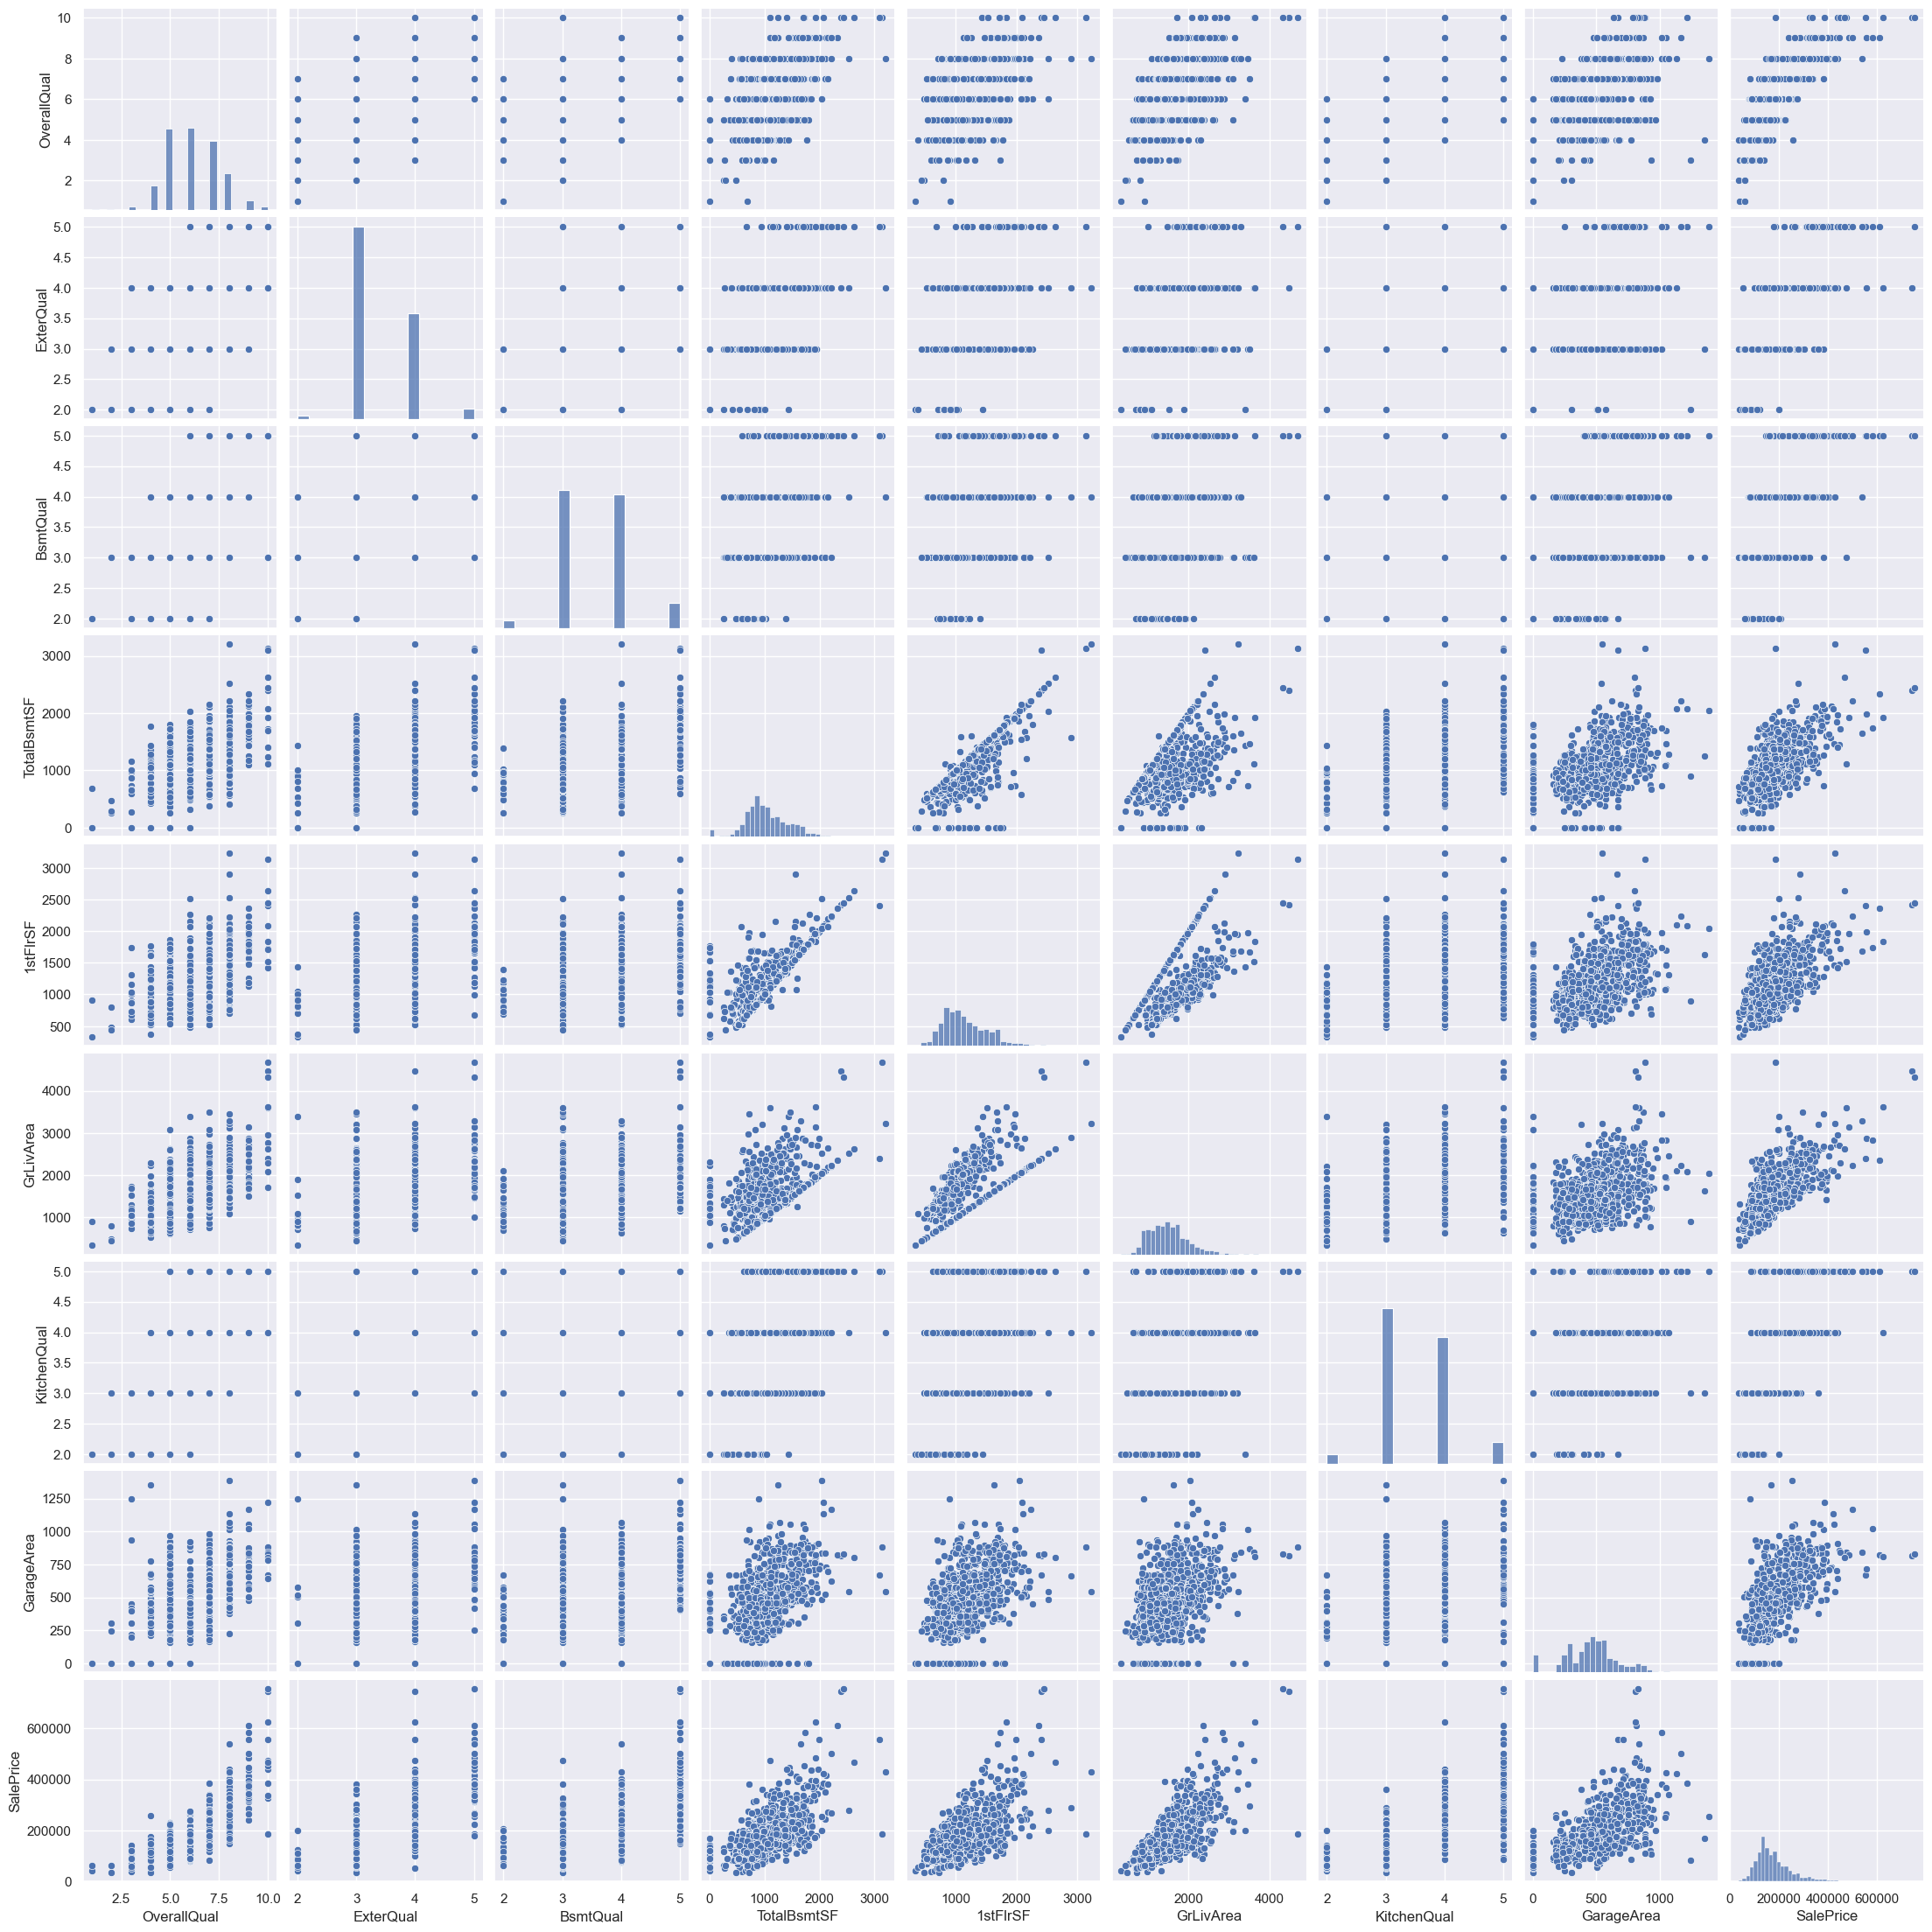

In [34]:
sns.pairplot(train_df_cleaned.select_dtypes(include="number"))



### Imputación de Datos

In [35]:
train_df_cleaned.info()

missing_summary = (
    train_df_cleaned.isna()
    .sum()
    .to_frame(name="datos_faltantes")
    .assign(
        porcentaje_faltante=lambda dataframe: (
            dataframe["datos_faltantes"] / len(train_df_cleaned) * 100
        ).round(2)
    )
    .sort_values("porcentaje_faltante", ascending=False)
 )

missing_summary[missing_summary["datos_faltantes"] > 0]

<class 'pandas.core.frame.DataFrame'>
Index: 1167 entries, 1333 to 1199
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   OverallQual   1167 non-null   int64  
 1   ExterQual     1167 non-null   int64  
 2   BsmtQual      1139 non-null   float64
 3   TotalBsmtSF   1167 non-null   int64  
 4   CentralAir    1167 non-null   object 
 5   1stFlrSF      1167 non-null   int64  
 6   GrLivArea     1167 non-null   int64  
 7   KitchenQual   1167 non-null   int64  
 8   GarageFinish  1101 non-null   object 
 9   GarageArea    1167 non-null   int64  
 10  SalePrice     1167 non-null   int64  
dtypes: float64(1), int64(8), object(2)
memory usage: 109.4+ KB


,datos_faltantes,porcentaje_faltante
GarageFinish,66,5.66
BsmtQual,28,2.40


Se hace el relleno de datos faltantes con dos estrategias: 

* Para la variable categorica, se asigna una nueva categoria llamada missing
* Para la variable numerica, se rellena con la estretagia de la media


In [36]:
bsmtqual_mean = train_df_cleaned["BsmtQual"].mean()

train_df_cleaned["GarageFinish"] = train_df_cleaned["GarageFinish"].fillna("missing")
train_df_cleaned["BsmtQual"] = train_df_cleaned["BsmtQual"].fillna(train_df_cleaned["BsmtQual"].mean())


In [37]:
c="GarageFinish"
train_df_cleaned[c].value_counts()

GarageFinish
Fin        620
Unf        481
missing     66
Name: count, dtype: int64

In [38]:
train_df_cleaned.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1167 entries, 1333 to 1199
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   OverallQual   1167 non-null   int64  
 1   ExterQual     1167 non-null   int64  
 2   BsmtQual      1167 non-null   float64
 3   TotalBsmtSF   1167 non-null   int64  
 4   CentralAir    1167 non-null   object 
 5   1stFlrSF      1167 non-null   int64  
 6   GrLivArea     1167 non-null   int64  
 7   KitchenQual   1167 non-null   int64  
 8   GarageFinish  1167 non-null   object 
 9   GarageArea    1167 non-null   int64  
 10  SalePrice     1167 non-null   int64  
dtypes: float64(1), int64(8), object(2)
memory usage: 109.4+ KB


### Codificación de Variables Categoricas finales

Se lleva al one-hot-encoding las variables central air y GarageFinish


In [39]:
import numpy as np

def to_onehot(x, values):
    r = np.r_[[np.argwhere(i==values)[0][0] for i in x]]
    return np.eye(len(values))[r].astype(int)


def replace_column_with_onehot(d, col, values):
    assert sum(d[col].isna())==0, "column must have no NaN values"
    k = to_onehot(d[col].values, values)
    r = pd.DataFrame(k, columns=["%s_%s"%(col, values[i]) for i in range(k.shape[1])], index=d.index).join(d)
    del(r[col])
    return r

garagefinish_categories = np.unique(train_df_cleaned["GarageFinish"])
centralair_categories = np.unique(train_df_cleaned["CentralAir"])

train_df_cleaned = replace_column_with_onehot(train_df_cleaned, "GarageFinish", garagefinish_categories)
train_df_cleaned = replace_column_with_onehot(train_df_cleaned, "CentralAir", centralair_categories)

train_df_cleaned.head(10)

,CentralAir_N,CentralAir_Y,GarageFinish_Fin,GarageFinish_Unf,GarageFinish_missing,OverallQual,ExterQual,BsmtQual,TotalBsmtSF,1stFlrSF,GrLivArea,KitchenQual,GarageArea,SalePrice
1333,0,1,0,1,0,5,3,3.0,803,803,1360,4,297,125500
849,0,1,1,0,0,6,4,3.0,528,1094,1855,3,512,187000
647,0,1,1,0,0,6,3,3.0,1094,1094,1094,3,495,155000
501,0,1,1,0,0,7,4,4.0,866,866,1768,4,603,226700
1115,0,1,1,0,0,8,4,5.0,1734,1734,1734,5,928,318000
335,0,1,1,0,0,5,3,3.0,1499,1619,1786,3,529,228950
1410,0,1,1,0,0,7,4,4.0,944,944,1840,4,622,230000
651,0,1,0,1,0,4,3,3.0,755,755,1510,3,296,108000
1437,0,1,1,0,0,8,5,5.0,1932,1932,1932,5,774,394617
1267,0,1,1,0,0,9,5,5.0,2002,2018,2018,5,746,378500


### Estandatización / Normalización 

En el conjunto tenemos variables de calificación que van del 1-5 o 1-10; también se cuenta con variables tipo dummie para el garaje y si contiene aire acondicionado; finalmente, hay otras variables que describen el tamaño de los diferentes espacios (1 piso, sotano, garaje, etc.). Se procede con una estandarización para dichas variables y que contemos con una escala acorde a las otras predictoras

In [ ]:
from sklearn.preprocessing import StandardScaler

cols_a_escalar = ["TotalBsmtSF", "1stFlrSF", "GrLivArea", "GarageArea"]

scaler = StandardScaler()

# El scaler se ajusta (fit) SOLO con train_df_cleaned, para no filtrar informacion de test_df
scaler.fit(train_df_cleaned[cols_a_escalar])

train_df_cleaned[cols_a_escalar] = scaler.transform(train_df_cleaned[cols_a_escalar])

train_df_cleaned.head(10)

# Modelo

### Modelo Base

In [40]:
train_df_cleaned.head()

,CentralAir_N,CentralAir_Y,GarageFinish_Fin,GarageFinish_Unf,GarageFinish_missing,OverallQual,ExterQual,BsmtQual,TotalBsmtSF,1stFlrSF,GrLivArea,KitchenQual,GarageArea,SalePrice
1333,0,1,0,1,0,5,3,3.0,803,803,1360,4,297,125500
849,0,1,1,0,0,6,4,3.0,528,1094,1855,3,512,187000
647,0,1,1,0,0,6,3,3.0,1094,1094,1094,3,495,155000
501,0,1,1,0,0,7,4,4.0,866,866,1768,4,603,226700
1115,0,1,1,0,0,8,4,5.0,1734,1734,1734,5,928,318000


Se escoge un modelo de mediana, dado que la distribución de variable objetivo tiene valores extremos, lo cual la media como modelo base tendría peor desemepeño

In [41]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Separacion de features y target a partir de train_df_cleaned
X_train = train_df_cleaned.drop(columns=[ "SalePrice"])
y_train = train_df_cleaned["SalePrice"]

# Modelo base: siempre predice la mediana de SalePrice
baseline_model = DummyRegressor(strategy="median")
baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_train)

print("Mediana predicha (constante):", round(float(baseline_model.constant_[0][0]), 2))
print("MAE  baseline:", round(mean_absolute_error(y_train, y_pred_baseline), 2))
print("RMSE baseline:", round(np.sqrt(mean_squared_error(y_train, y_pred_baseline)), 2))
print("R2   baseline:", round(r2_score(y_train, y_pred_baseline), 2))

Mediana predicha (constante): 163500.0
MAE  baseline: 55952.49
RMSE baseline: 82991.75
R2   baseline: -0.05


### Preparación de Conjunto Test

In [ ]:
# Columnas a eliminar segun los criterios de arriba
test_df_cleaned = test_df.drop(columns=columns_to_drop)
test_df_cleaned = test_df_cleaned.drop(columns=list(columns_to_drop_round2.keys()))
test_df_cleaned = test_df_cleaned.drop(columns=low_correlation_vars.index, errors="ignore")
test_df_cleaned = test_df_cleaned.drop(columns=["GarageCars"])

# Convertir datos categoricos a numericos  
for c in qual_cols:
    test_df_cleaned[c] = test_df_cleaned[c].map(qual_mapping)

# Transformacion de datos juntar clases 
test_df_cleaned["GarageFinish"] = test_df_cleaned["GarageFinish"].replace("RFn", "Fin")

# Imputacion de Datos
test_df_cleaned["GarageFinish"] = test_df_cleaned["GarageFinish"].fillna("missing")
test_df_cleaned["BsmtQual"] = test_df_cleaned["BsmtQual"].fillna(bsmtqual_mean)

# Variables dummies / one-hot encoding
test_df_cleaned = replace_column_with_onehot(test_df_cleaned, "GarageFinish", garagefinish_categories)
test_df_cleaned = replace_column_with_onehot(test_df_cleaned, "CentralAir", centralair_categories)


# Estandarización de variables tipo area

cols_a_escalar = ["TotalBsmtSF", "1stFlrSF", "GrLivArea", "GarageArea"]
test_df_cleaned[cols_a_escalar] = scaler.transform(test_df_cleaned[cols_a_escalar])


print("Test dataset shape despues de limpieza:", test_df_cleaned.shape)
test_df_cleaned.head()

In [ ]:
X_test = test_df_cleaned.drop(columns=["SalePrice"])
y_test = test_df_cleaned["SalePrice"]

X_test = X_test[X_train.columns]

### Modelo Entrenamiento y Validación

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold
import pandas as pd

X_train = train_df_cleaned.drop(columns=["SalePrice"])
y_train = train_df_cleaned["SalePrice"]
modelos = {
    "Modelo Base (Mediana)": DummyRegressor(strategy="median"),
    "Regresion Lineal": LinearRegression(),
    "Ridge": Ridge(random_state=80),
    "Lasso": Lasso(random_state=80),
    "Random Forest Regressor": RandomForestRegressor(random_state=80),
    "XGBoost Regressor": XGBRegressor(random_state=80),
}


comparacion_traintest = []
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
   


    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    comparacion_traintest.append({
        "Modelo": nombre,
        "MAE Train": round(mean_absolute_error(y_train, y_pred_train), 2),
        "MAE Test": round(mean_absolute_error(y_test, y_pred_test), 2),
        "RMSE Train": round(np.sqrt(mean_squared_error(y_train, y_pred_train)), 2),
        "RMSE Test": round(np.sqrt(mean_squared_error(y_test, y_pred_test)), 2),
        "R2 Train": round(r2_score(y_train, y_pred_train), 2),
        "R2 Test": round(r2_score(y_test, y_pred_test), 2),
    })

comparacion_traintest_df = pd.DataFrame(comparacion_traintest)
comparacion_traintest_df

Hacemos varios modelos a competir con los que dieron buenos resultados y es posible cambiar el parametro, excluyendo los modelos de Random forest regressor y XGBoost regressor, ya que estos para pocos datos tienden a memorizar el ruido (overfitting)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.dummy import DummyRegressor
import pandas as pd

X_train = train_df_cleaned.drop(columns=["SalePrice"])
y_train = train_df_cleaned["SalePrice"]

modelos_parametros = {
    "Modelo Base (Mediana)": DummyRegressor(strategy="median"),
    "Regresion Lineal": LinearRegression(),
    "Ridge (alpha=0.1)": Ridge(alpha=0.1, random_state=80),
    "Ridge (alpha=1)": Ridge(alpha=1, random_state=80),
    "Ridge (alpha=10)": Ridge(alpha=10, random_state=80),
    "Ridge (alpha=100)": Ridge(alpha=100, random_state=80),
    "Lasso (alpha=0.1)": Lasso(alpha=0.1, random_state=80),
    "Lasso (alpha=1)": Lasso(alpha=1, random_state=80),
    "Lasso (alpha=10)": Lasso(alpha=10, random_state=80),
    "Lasso (alpha=100)": Lasso(alpha=100, random_state=80),
    
}



comparacion_parametros = []
for nombre, modelo in modelos_parametros.items():
    modelo.fit(X_train, y_train)

    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    comparacion_parametros.append({
        "Modelo": nombre,
        "MAE Train": round(mean_absolute_error(y_train, y_pred_train), 2),
        "MAE Test": round(mean_absolute_error(y_test, y_pred_test), 2),
        "RMSE Train": round(np.sqrt(mean_squared_error(y_train, y_pred_train)), 2),
        "RMSE Test": round(np.sqrt(mean_squared_error(y_test, y_pred_test)), 2),
        "R2 Train": round(r2_score(y_train, y_pred_train), 2),
        "R2 Test": round(r2_score(y_test, y_pred_test), 2),
    })

comparacion_parametros_df = pd.DataFrame(comparacion_parametros)
comparacion_parametros_df

### Interpretación de Resultados

Se bajo de un error de 55 mil dolares a 20 mil, obteniendo R2 cerca al 81% con el sorrandom Forest Regres

### Evaluación Modelo Conjunto Validación

Competición de modelos

# Almacenamiento Modelo

### Creación de Pipeline de Transformación de Datos

### Guardar modelo en formato joblib